<a href="https://colab.research.google.com/github/ANDRIUW9401/ACTIVIDAD-4-GITHUB/blob/master/Actividad_4_M%C3%A9todos_de_aprendizaje_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Datos:
   hora_dia  dia_semana  clima  demanda_pasajeros  retraso_min
0         6           1      1                114           19
1        19           5      0                466           24
2        14           1      0                217           17
3        10           1      0                379           14
4         7           3      1                 92            8


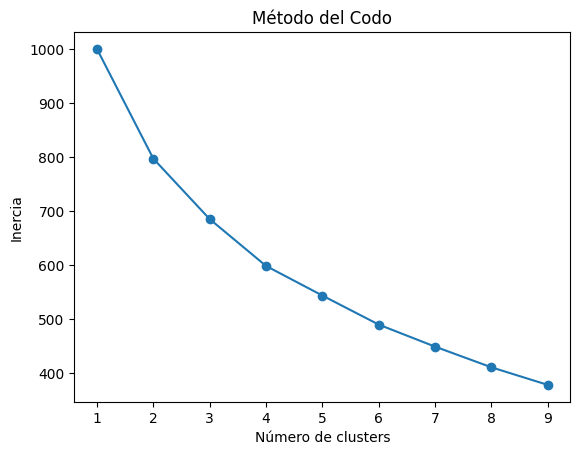


Datos con clusters:
   hora_dia  dia_semana  clima  demanda_pasajeros  retraso_min  cluster
0         6           1      1                114           19        0
1        19           5      0                466           24        1
2        14           1      0                217           17        2
3        10           1      0                379           14        2
4         7           3      1                 92            8        0


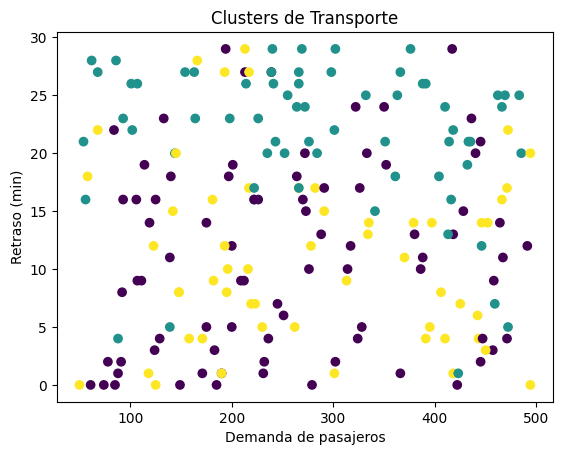


Promedio por cluster:
          hora_dia  dia_semana     clima  demanda_pasajeros  retraso_min
cluster                                                                 
0        10.250000    2.862500  1.000000         256.700000    11.062500
1        14.169231    5.769231  0.461538         286.784615    21.430769
2         8.345455    2.745455  0.000000         279.418182    11.127273


In [2]:
# =====================================
# 1. IMPORTAR LIBRERÍAS
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# =====================================
# 2. CREAR DATASET (SIMULADO)
# =====================================
np.random.seed(42)

data = pd.DataFrame({
    'hora_dia': np.random.randint(0, 24, 200),
    'dia_semana': np.random.randint(1, 8, 200),
    'clima': np.random.choice([0, 1], 200),  # 0=soleado, 1=lluvia
    'demanda_pasajeros': np.random.randint(50, 500, 200),
    'retraso_min': np.random.randint(0, 30, 200)
})

print("Datos:")
print(data.head())

# =====================================
# 3. PREPROCESAMIENTO
# =====================================
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# =====================================
# 4. MÉTODO DEL CODO (ELBOW)
# =====================================
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    inertia.append(kmeans.inertia_)

# Gráfica del codo
plt.figure()
plt.plot(range(1, 10), inertia, marker='o')
plt.title("Método del Codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.show()

# =====================================
# 5. ENTRENAR MODELO K-MEANS
# =====================================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(data_scaled)

data['cluster'] = clusters

print("\nDatos con clusters:")
print(data.head())

# =====================================
# 6. VISUALIZACIÓN
# =====================================
plt.figure()
plt.scatter(data['demanda_pasajeros'], data['retraso_min'], c=clusters)
plt.xlabel("Demanda de pasajeros")
plt.ylabel("Retraso (min)")
plt.title("Clusters de Transporte")
plt.show()

# =====================================
# 7. ANÁLISIS DE CLUSTERS
# =====================================
print("\nPromedio por cluster:")
print(data.groupby('cluster').mean())